In [6]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.impute import SimpleImputer

# Load the data
train_df = pd.read_csv('Train_data.csv')
test_df = pd.read_csv('Test_data.csv')

# View shape and basic info
print("Training data shape:", train_df.shape)
print("Testing data shape:", test_df.shape)

# Extract labels
y_train = train_df['class']
X_train = train_df.drop(['class'], axis=1)

# Handle test data
if 'class' in test_df.columns:
    y_test = test_df['class']
    X_test = test_df.drop(['class'], axis=1)
else:
    y_test = None
    X_test = test_df

# Encode categorical features safely using combined data
categorical_columns = ['protocol_type', 'service', 'flag']
encoders = {}

for col in categorical_columns:
    le = LabelEncoder()
    combined_data = pd.concat([X_train[col], X_test[col]], axis=0)
    le.fit(combined_data)
    X_train[col] = le.transform(X_train[col])
    X_test[col] = le.transform(X_test[col])
    encoders[col] = le  # save encoder for future use if needed

# Encode class labels
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
if y_test is not None:
    y_test = label_encoder.transform(y_test)

# Handle missing values (NaNs) using SimpleImputer
imputer = SimpleImputer(strategy='most_frequent')  # You can change to 'mean' or 'median' if preferred
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

# Ensure encoded categorical columns are int
for col in categorical_columns:
    X_train[col] = X_train[col].astype(int)
    X_test[col] = X_test[col].astype(int)

# Train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Evaluate the model
if y_test is not None:
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
else:
    print("Predictions on test data (no labels available):")
    print(label_encoder.inverse_transform(y_pred))


Training data shape: (25192, 42)
Testing data shape: (25192, 42)
Accuracy: 0.5104398221657669
Classification Report:
               precision    recall  f1-score   support

           0       0.46      0.33      0.39     11743
           1       0.53      0.67      0.59     13449

    accuracy                           0.51     25192
   macro avg       0.50      0.50      0.49     25192
weighted avg       0.50      0.51      0.50     25192



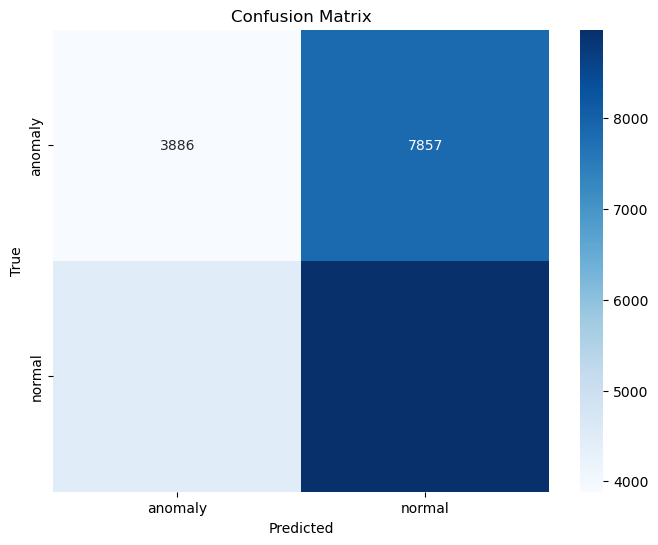

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


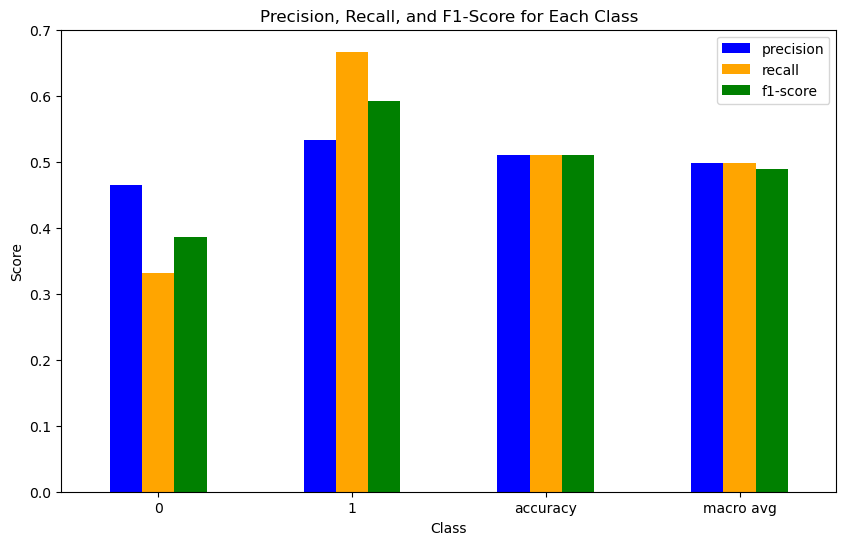

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# Get classification report
report = classification_report(y_test, y_pred, output_dict=True)

# Convert to DataFrame
report_df = pd.DataFrame(report).transpose()

# Plot precision, recall, F1-score for each class
report_df[['precision', 'recall', 'f1-score']].iloc[:-1].plot(kind='bar', figsize=(10, 6), color=['blue', 'orange', 'green'])
plt.title('Precision, Recall, and F1-Score for Each Class')
plt.xlabel('Class')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.show()


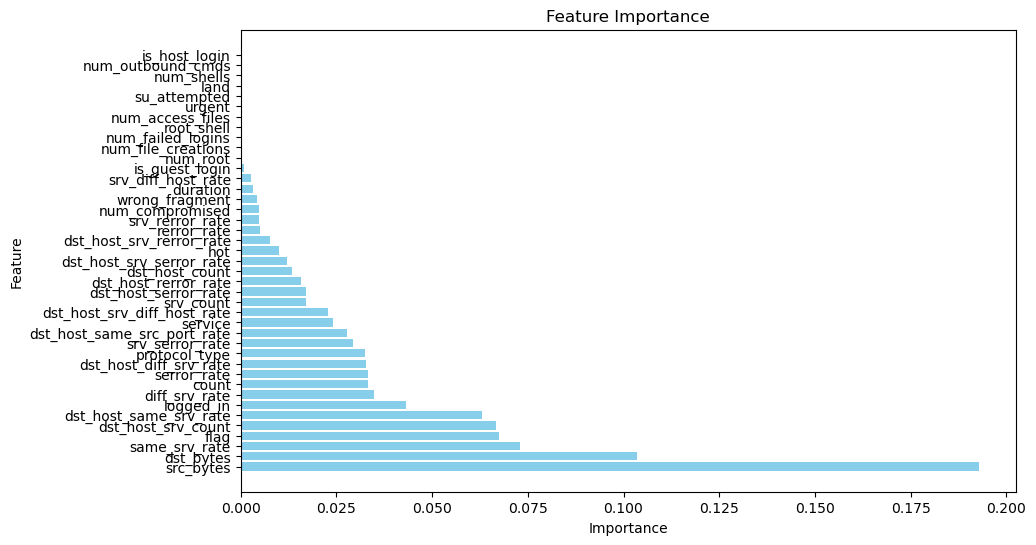

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Get feature importance from the trained model
feature_importances = model.feature_importances_

# Create a DataFrame for better visualization
features = X_train.columns
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
})

# Sort the features by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()
